# 🌱 1. Analiza Exploratorie de Date (EDA) - Modulul Pedoclimatic

Acest notebook realizează auditul statistic preliminar al matricii datelor structurate. Analizăm distribuțiile de macro-nutrienți (N, P, K) și corelațiile pedoclimatice matematice.

### Argumentarea Strategiei de Imputare în Producție:
Deși setul de antrenare curat prezintă zero valori nule, în cod integrăm preventiv un bloc `SimpleImputer(strategy='median')`. Această măsură structurală garantează reziliența în producție a aplicației `app.py` împotriva erorilor de rețea, pachetelor pierdute sau căderilor senzorilor IoT din teren.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import os

sns.set_theme(style="whitegrid")
df_soil = pd.read_csv('../data/raw/Crop_recommendation.csv')
print("Dimensiune date inițiale:", df_soil.shape)

Dimensiune date inițiale: (2200, 8)


## 1.2 Profilarea Densităților prin Violin Plots
Violin plot-urile ne permit să observăm simultan densitatea de probabilitate și momentele statistice principale pentru macro-nutrienți (ex: Potasiu - K), izolând profilul idealizat de cel regional.

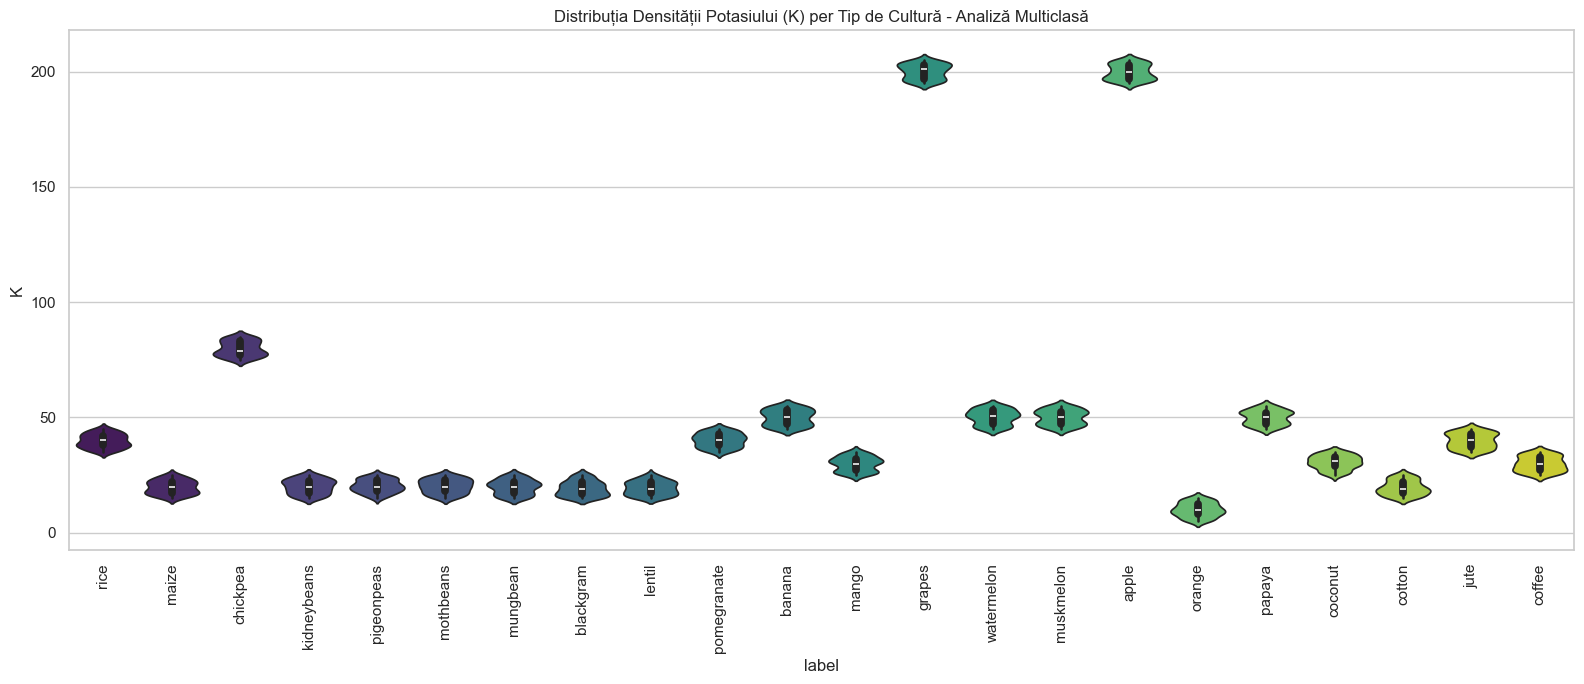

In [3]:
plt.figure(figsize=(16, 7))
sns.violinplot(x='label', y='K', data=df_soil, palette='viridis', hue='label', legend=False)
plt.xticks(rotation=90)
plt.title('Distribuția Densității Potasiului (K) per Tip de Cultură - Analiză Multiclasă')
plt.tight_layout()
os.makedirs('../demo_files', exist_ok=True)
plt.savefig('../demo_files/violin_plot_potasiu.png')
plt.show()

## 1.3 Reducerea Dimensionalității și Vizualizarea Spațiului Trăsăturilor (PCA)
Aplicăm o transformare PCA pe cele 7 dimensiuni pedoclimatice scalate pentru a inspecta gradul de separabilitate liniară al claselor de cultură.

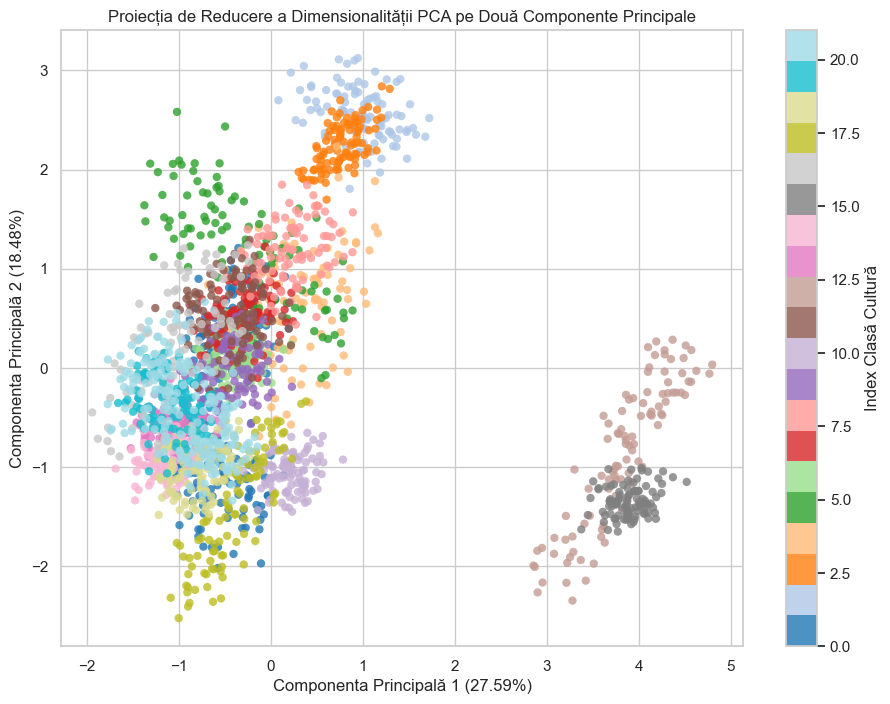

In [4]:
X = df_soil.drop('label', axis=1)
y_labels, clase_unice = pd.factorize(df_soil['label'])

X_imputed = SimpleImputer(strategy='median').fit_transform(X)
X_scaled = StandardScaler().fit_transform(X_imputed)

pca_engine = PCA(n_components=2)
X_pca = pca_engine.fit_transform(X_scaled)

plt.figure(figsize=(11, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_labels, cmap='tab20', alpha=0.8, edgecolors='none')
plt.colorbar(scatter, label='Index Clasă Cultură')
plt.title('Proiecția de Reducere a Dimensionalității PCA pe Două Componente Principale')
plt.xlabel(f'Componenta Principală 1 ({pca_engine.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Componenta Principală 2 ({pca_engine.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()